# Machine learning 

Here we will illustrate some illustrations relevant for evaluation of prediction models. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plot_misc.machine_learning as ml
import plot_misc.example_data.examples as examples
from matplotlib.lines import Line2D
from statsmodels.nonparametric.smoothers_lowess import lowess

In [2]:
# constants
X_LAB = 'c-statistic change'
LAB_SIZE=14
LAB_PAD=1.2
TICKS_WD = 0.6
TLAB_SIZE = 9
TLEN = 5
VALUES='importance'
LABELS='name'
CMTOINCH = 1/2.54

# import example data
data = examples.load_lollipop_data()
data = data[data[VALUES] > 0]
data.head()

,name,importance
0,Height (cm),0.046065
1,Female sex,0.043915
2,R-axis (degrees),0.036310
3,History of LTVA,0.027412
4,ECG Embeding 26,0.020835


## Lollipop plots


Lollipop plots are a clean alternative to bar plots, especially for visualising ranked values such as feature importance or effect sizes. 
Each line connects a baseline (usually zero) to a value, ending in a dot. 
They are particularly useful when space is limited or to emphasise ordering.

(0.0, 0.048247475455820456)

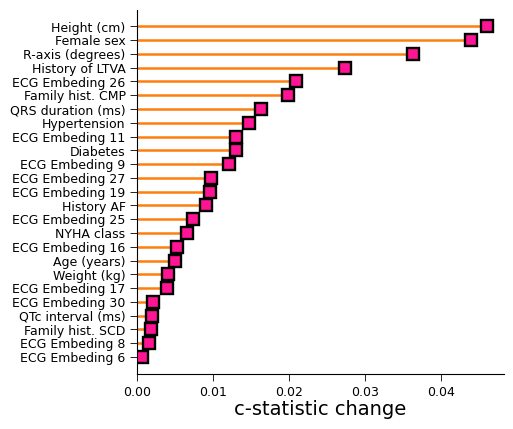

In [3]:
fig, ax = plt.subplots(1, figsize=(12*CMTOINCH, 12*CMTOINCH))

# make plot
_, ax = ml.lollipop(
     values=data[VALUES].to_numpy(), labels=data[LABELS].to_numpy(),
    line_colour='tab:orange', linewidth=1.8, dot_color='deeppink', 
    dot_edge_color='black', dot_size=8, dot_edge_size=1.7, reverse_feature_order=True, 
    ax=ax, kwargs_plot_dict={'marker':'s'},
                    )
# labels and ticks
ax.tick_params(axis="x", labelsize=TLAB_SIZE, length=TLEN, width=TICKS_WD,
        rotation=0)
ax.tick_params(axis="y", labelsize=TLAB_SIZE, length=TLEN, width=TICKS_WD,
        rotation=0)
# add lables
ax.set_ylabel('')
ax.set_xlabel(X_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)
# limits
xlim = ax.get_xlim()
ax.set_xlim(0, xlim[1]*0.95)

### A vertical lollipop 

(0.0, 0.048247475455820456)

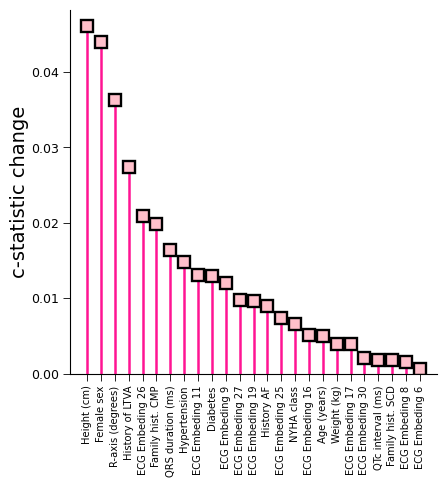

In [4]:
# A vertical version
fig, ax = plt.subplots(1, figsize=(12*CMTOINCH, 12*CMTOINCH))

# make plot
_, ax = ml.lollipop(
     values=data[VALUES].to_numpy(), labels=data[LABELS].to_numpy(),
    line_colour='deeppink', linewidth=1.8, dot_color='pink', 
    dot_edge_color='black', dot_size=8, dot_edge_size=1.7, reverse_feature_order=False, 
    vertical=True,
    ax=ax, kwargs_plot_dict={'marker':'s'},
                    )
# labels and ticks
ax.tick_params(axis="x", labelsize=TLAB_SIZE*.8, length=TLEN, width=TICKS_WD,
        rotation=90)
ax.tick_params(axis="y", labelsize=TLAB_SIZE, length=TLEN, width=TICKS_WD,
        rotation=0)
# add lables
ax.set_xlabel('')
ax.set_ylabel(X_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)
# limits
ylim = ax.get_ylim()
ax.set_ylim(0, ylim[1]*0.95)

## Calibration plots

Calibration plots compare predicted value from a model to the actual observed value of an outcome. Ideally, well-calibrated predictions should lie on the diagonal, where predicted and observed risks are equal. These plots
are useful for assessing the reliability of (probabilistic) models.

In [5]:
# load data 
data = examples.load_calibration_bins()

# constants
X_LAB = 'Predicted risk'
Y_LAB = 'Observed risk'
LINE_COL = ['lightcoral', 'lightgreen']
LINE_LW = [1.5, 1.5]
LINE_LS = ['--', '--']
DOT_COL = ['lightcoral', 'lightgreen']
DOT_MARK = ['o', 'o']

data.head()

,average_predict_risk,average_observed_risk,lower_observed_risk,upper_observed_risk,no_subjects
bins,,,,,
0,0.077704,0.071429,0.008770,0.235035,28
1,0.158541,0.178571,0.060643,0.368933,28
2,0.238182,0.285714,0.132237,0.486668,28
3,0.340155,0.259259,0.111145,0.462849,27
4,0.468930,0.464286,0.275109,0.661301,28


Text(0.5, 0, 'Predicted risk')

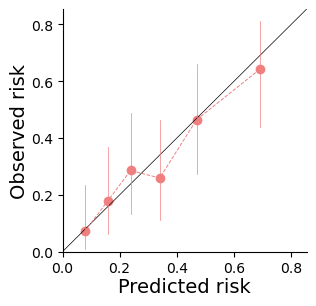

In [6]:
# make figure
fig, ax = plt.subplots(1, figsize=(8*CMTOINCH, 8*CMTOINCH))

# make plot
ml.Calibration(data, ax=ax).plot(predicted='average_predict_risk', observed='average_observed_risk',
                                         lower_observed='lower_observed_risk', upper_observed='upper_observed_risk',
                                        )
# labels
ax.set_ylabel(Y_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)
ax.set_xlabel(X_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)

### Plotting a curve instead of line segments

Next, we can plot a smooth curve instead of the previous line segments. To achieve this, we set `line_linestyle` to an empty string (`''`), which suppresses the default line segments. We then pass a keyword argument (kwargs) to the curves object specifying the desired linestyle for the fitted curves. By default, both the line segments and the curves will share the same visual properties, including colour, line width, and style, unless explicitly overridden.

Text(0.5, 0, 'Predicted risk')

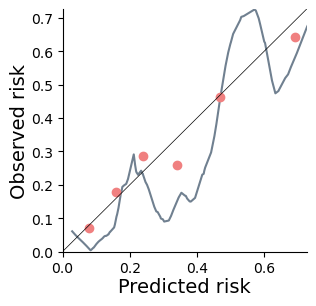

In [7]:
# make figure
fig, ax = plt.subplots(1, figsize=(8*CMTOINCH, 8*CMTOINCH))
,
# make plot
cal_plot = ml.Calibration(data, ax=ax).plot(predicted='average_predict_risk', observed='average_observed_risk', 
                                         line_linestyle=' ')
cal_plot.add_curves(data=examples.load_calibration_data(), smoother=lowess,
                    kwargs_smoother= {"return_sorted":False, 'it':2,"frac": 1/5,},
                    kwargs_curve={'linestyle': '-', 'c':'slategrey', 'linewidth':1.5, 'zorder':0}, 
                   )

# labels
ax.set_ylabel(Y_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)
ax.set_xlabel(X_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)

### Plotting multiple calibration lines

The function can also be used to depict the calibration off multiple models on a single plot, simply supply a dictionary with data from multiple models. _Note_: plotting multiple models on a single plot can quickly become cluttered. In practice, a multi-panel plot may be preferable.

Text(0.5, 0, 'Predicted risk')

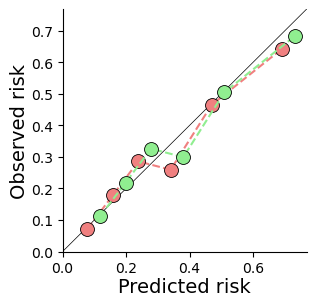

In [8]:
# multiple lines
data2 = data.copy()
data2[['average_predict_risk', 'average_observed_risk']] = \
     data2[['average_predict_risk', 'average_observed_risk']] + 0.04
# making dict
data_dict = {'one': data, 'two': data2}

# make figure
fig, ax = plt.subplots(1, figsize=(8*CMTOINCH, 8*CMTOINCH))

# make plot
ml.Calibration(data_dict, ax=ax).plot(
    predicted='average_predict_risk', observed='average_observed_risk',
                       ci_colour=None, ci_linewidth=None, 
                       dot_marker=DOT_MARK, dot_colour=DOT_COL, 
                       line_colour=LINE_COL, line_linestyle=LINE_LS, line_linewidth=LINE_LW,
                       kwargs_dot_dict={'s':100, 'edgecolor':'black', 'linewidths':0.6, 'zorder':2},
                       )
# labels
ax.set_ylabel(Y_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)
ax.set_xlabel(X_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)

## Decision curve plots
Decision cruve analysis compares the net-benefit (representing the pendalised difference between true and false positives) of any number of models across a decision threshold (the predicted probabilities). Typically these plots include extereme models were either everyone is treated or not. 

Below, the same plot is shown with and without smoothing. While the class internally applies LOWESS smoothing by default, it also allows the user to provide an alternative smoothing method as a callable function that returns the y-axis values.

(<Figure size 300x300 with 1 Axes>,
 <Axes: xlabel='Threshold', ylabel='Net benefit'>)

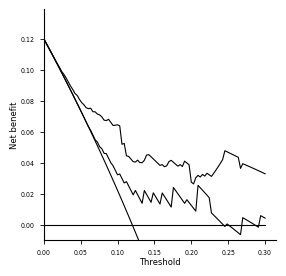

In [9]:
# import example data
data = examples.load_net_benefit_data()
# calculate the net benefit
nb_obj = ml.DecisionCurve(data)
nb_obj.calc_net_benefit(
    outcome='Composite outcome',modelnames=['DCM-PROGRESS', 'maggic (3-years risk of death)'],
    thresholds=list(np.linspace(0.0, 0.3, 100)),
)
# plotting
nb_obj.plot(figsize=(3,3), smoother=None,
)

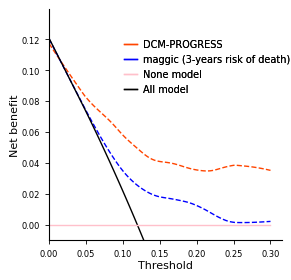

In [10]:
# Let's add some more colour and linetypes, and smoothing
MODEL_NAMES = nb_obj.MODEL_NAMES
COL_DICT = {k:j for j, k in zip(['orangered', 'blue', 'pink', 'black'], MODEL_NAMES)}
LINE_DICT = {k:j for j, k in zip(['--', '--', '-', '-'], MODEL_NAMES)}
nb_obj.LABEL_FONT_SIZE=8
nb_obj.TICK_LAB_SIZE=6
# plotting
f, ax = nb_obj.plot(figsize=(3,3), col_dict=COL_DICT, line_dict=LINE_DICT, 
           linewidth=1, kwargs_smoother={'it':3, 'frac':1/3, 
                                         "return_sorted":False,
                                        })
# adding a legend
cmap = COL_DICT
patches = [Line2D([0], [0], color=v, label=k, lw=1) for k, v in cmap.items()]
leg1 = ax.legend(handles=patches , ncol=1,                
                    loc = 'center',
                    bbox_to_anchor=(0.68, 0.75),
                    borderpad=0.0, handlelength=1.3,columnspacing=0.0,
                    handletextpad=0.6, frameon=False, fancybox=False, shadow=False,
                    fontsize=7, markerscale=0.05,
                    )
ax.add_artist(leg1)

In [11]:
help(ml)

Help on module plot_misc.machine_learning in plot_misc:

NAME
    plot_misc.machine_learning

DESCRIPTION
    Figure templates for visualising performance and interpretability of
    machine learning models.
    
    This module provides reusable plotting utilities for common visualisations in
    machine learning workflows, including lollipop charts for feature importance,
    calibration plots for model reliability assessment, and decision curve
    analysis (DCA) plots for evaluating clinical utility.
    
    Functions
    ---------
    lollipop(values, labels, ...)
        Draws a lollipop chart (dot-and-line plot) for visualising feature
        importance or effect sizes.
    
    Classes
    -------
    Calibration
        A plotting template for comparing observed and predicted risk, with
        optional confidence intervals and calibration curves.
    
    DecisionCurve
        A class to compute and plot DCA, evaluating net benefit of prediction
        models across varyin